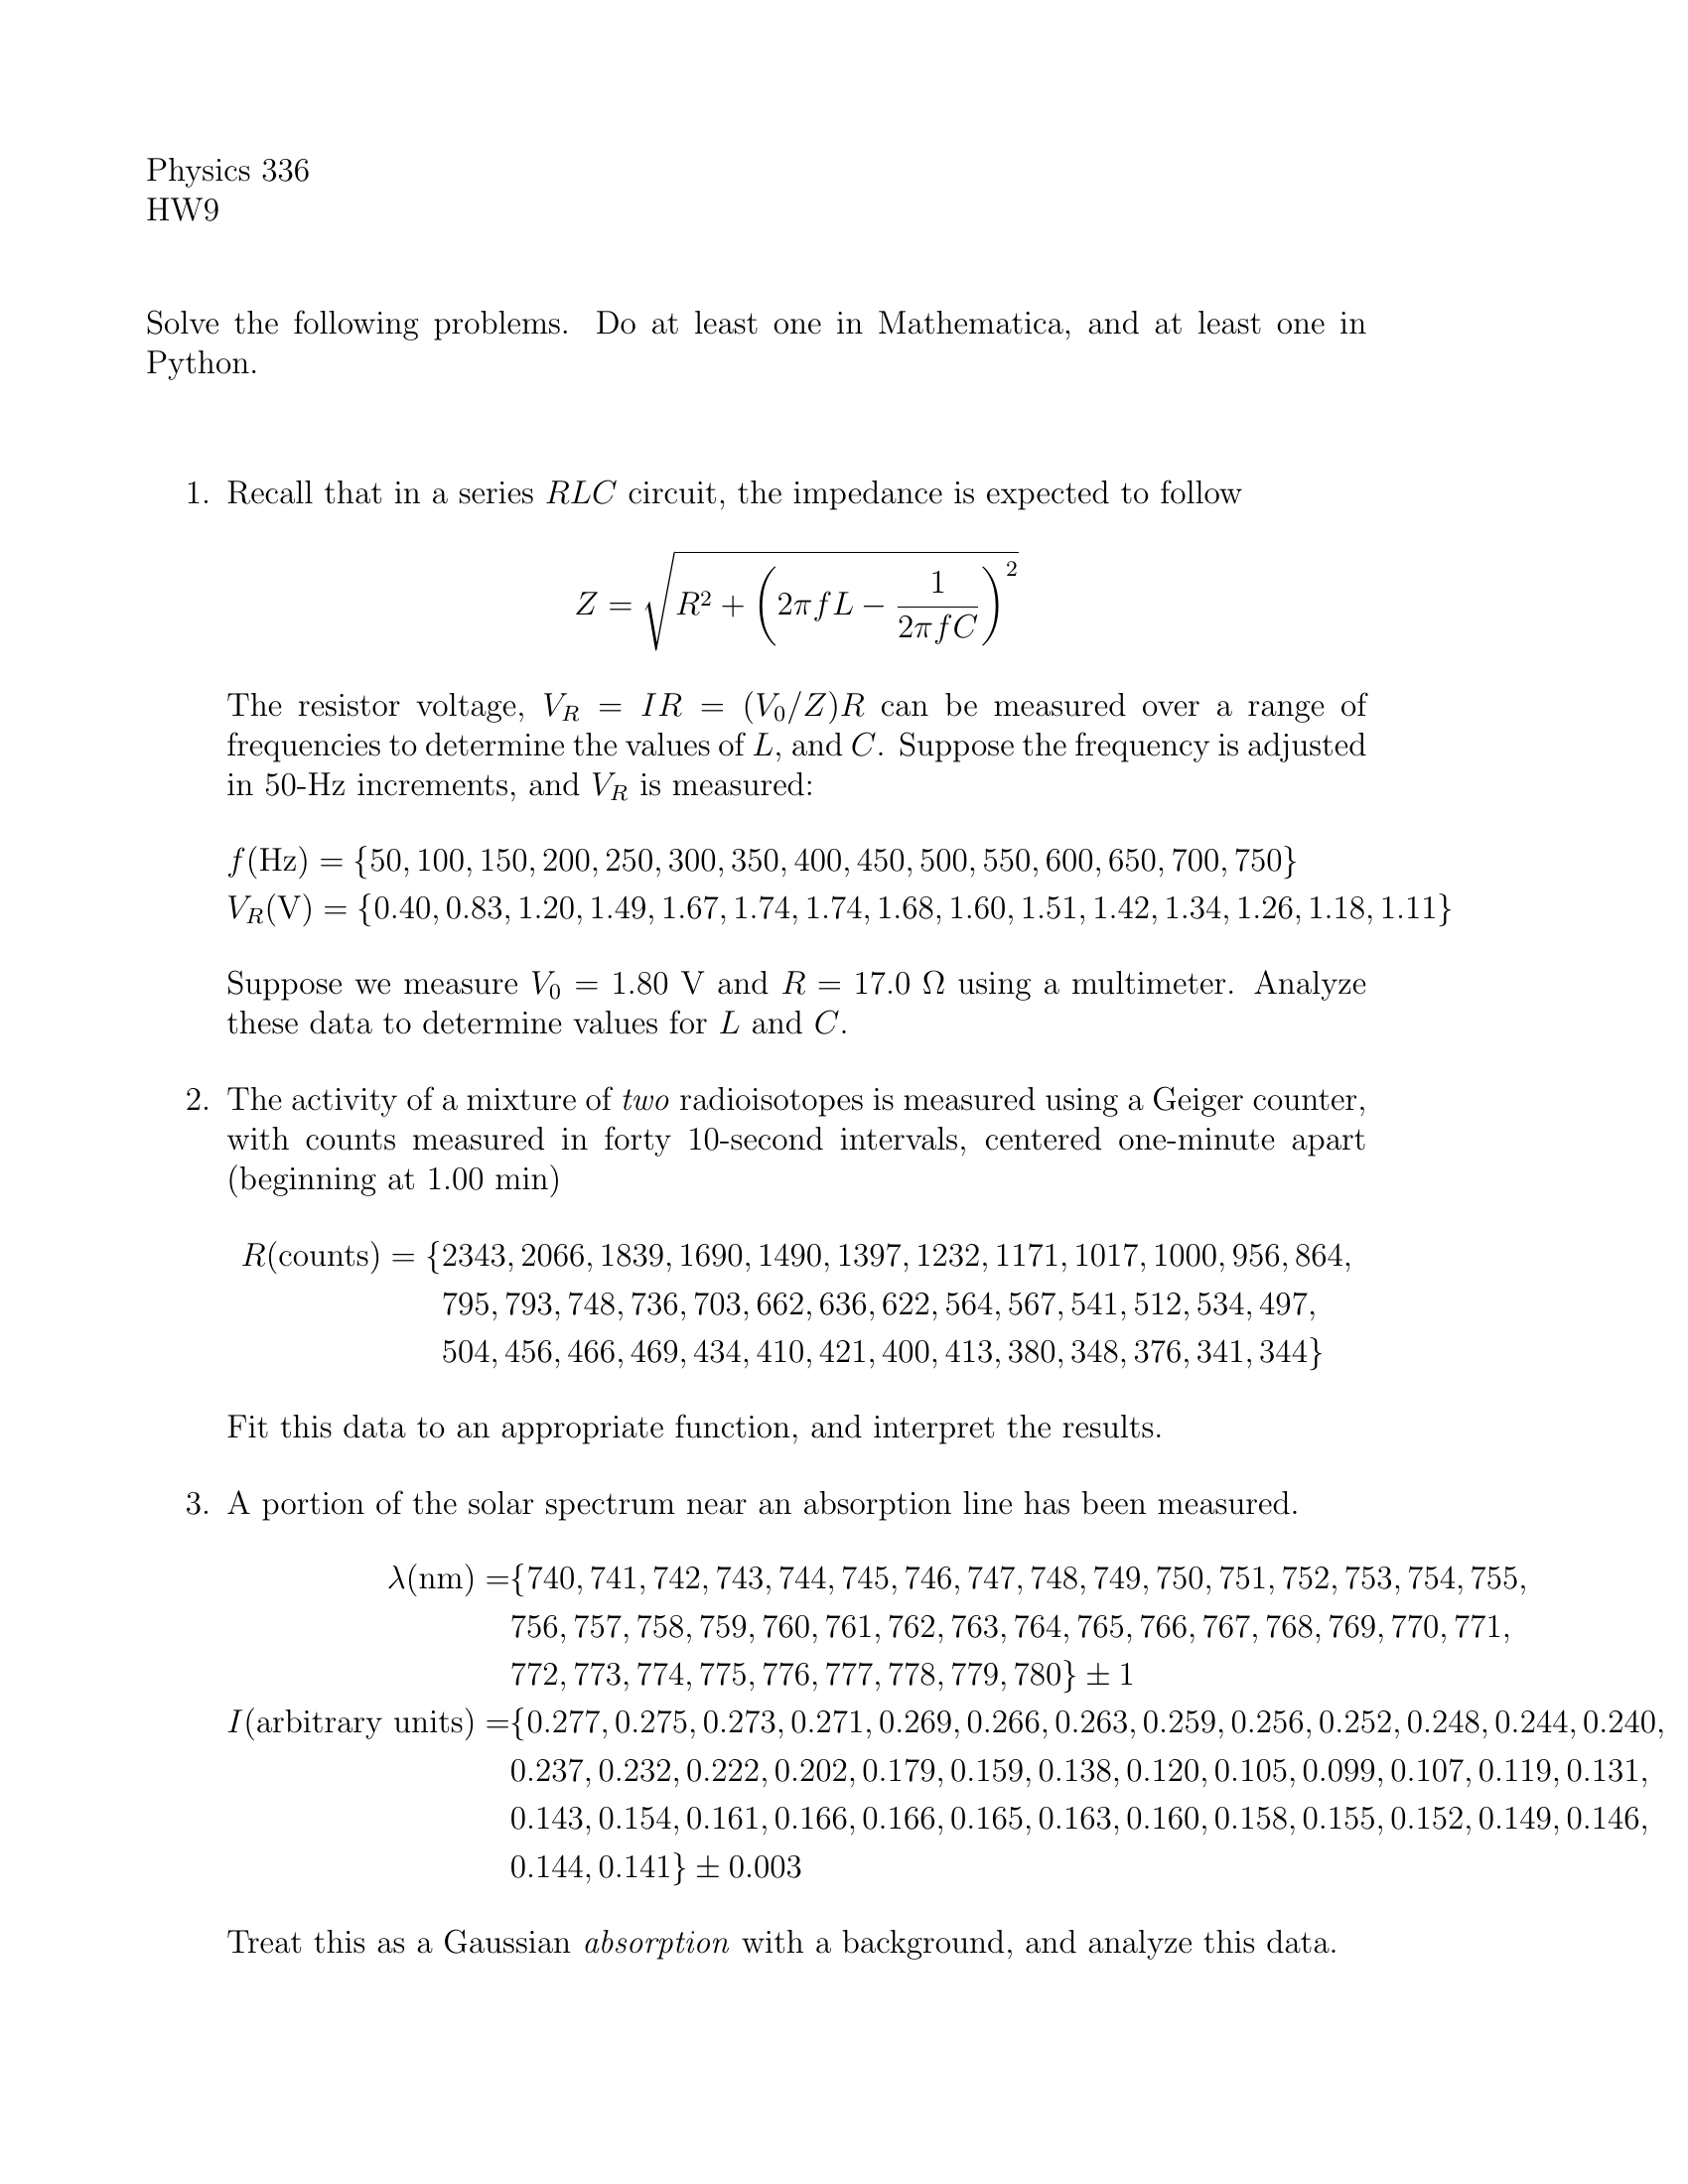

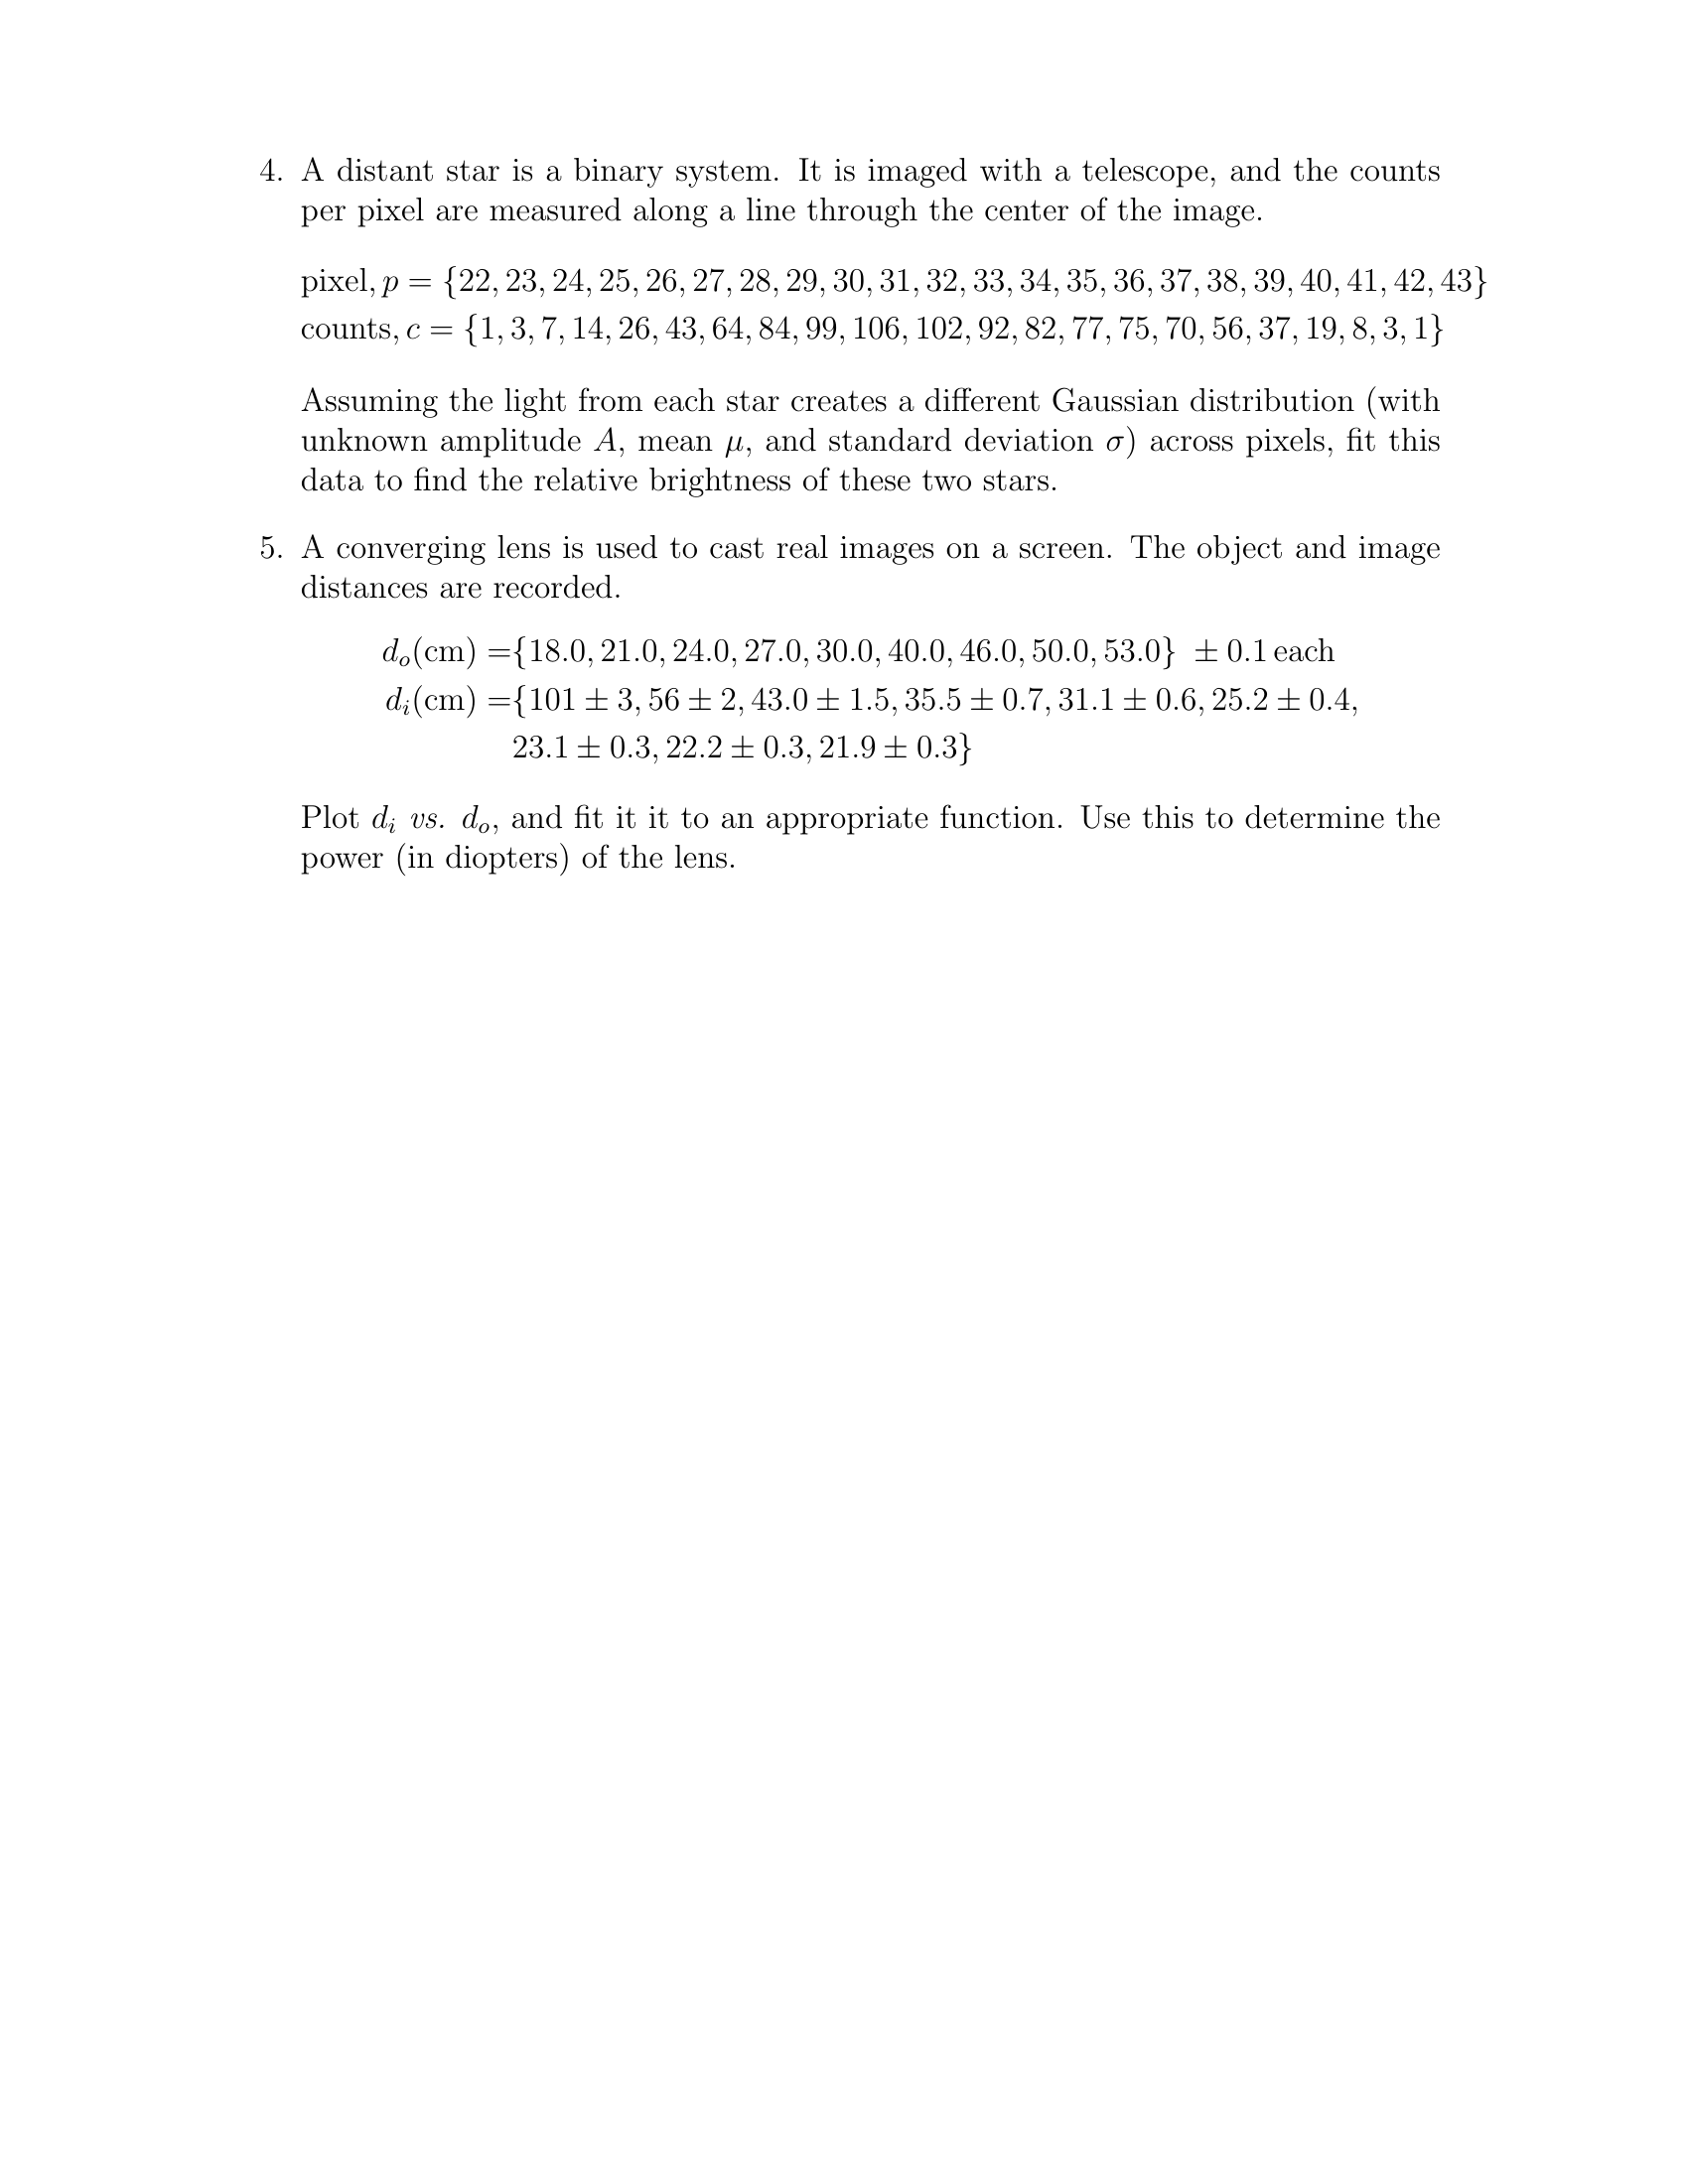

In [1]:
from pdf2image import convert_from_path
from IPython.display import display
images = convert_from_path(r"C:\Users\miles\BYU-Idaho\11th Semester\336 Advanced Lab\W09\336-hw9-a.pdf")
for img in images:
    display(img)

### Problem 1.

Fit Results:
L = 0.0057 ± 0.0001 H
C = 43.15 ± 0.88 uF


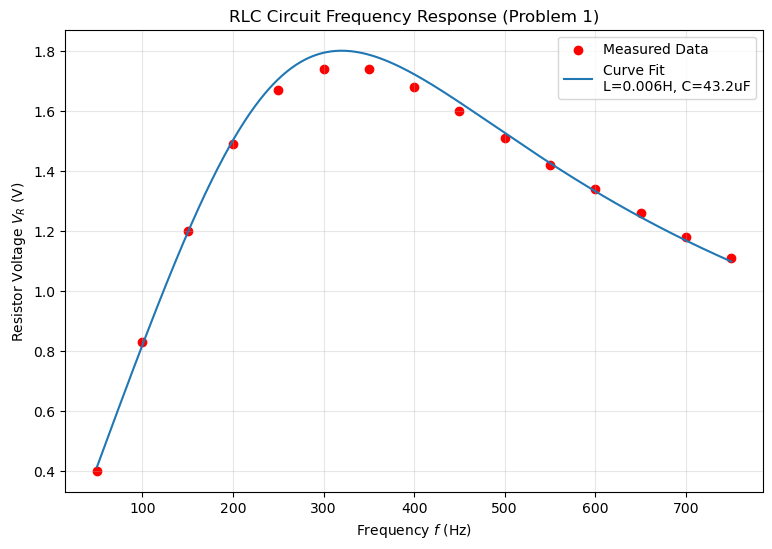

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

f=np.array([50,100,150,200,250,300,350,400,450,500,550,600,650,700,750])
V=np.array([0.4,0.83,1.2,1.49,1.67,1.74,1.74,1.68,1.60,1.51,1.42,1.34,1.26,1.18,1.11])
V0=1.8
R=17.0

def Vr(f,L,C):
    Z=np.sqrt(R**2+(2*np.pi*f*L-1/(2*np.pi*f*C))**2)
    VR=V0*R/Z
    return VR

L_guesses=np.linspace(0.005,0.006,100)
C_guesses=np.linspace(43e-6,44e-6,100)

min_guess=float('inf')

for i in L_guesses:
    for j in C_guesses:
        Vr_predicted=Vr(f,i,j)
        guess=np.sum((V-Vr_predicted)**2)
        if guess < min_guess:
            min_guess=guess
            best_L,best_C= i,j

initial_guesses=[best_L,best_C]

popt, pcov = curve_fit(Vr, f, V, p0=initial_guesses)

L_fit, C_fit = popt
dL, dC = np.sqrt(np.diag(pcov)) # Standard deviations of the parameters

print(f"Fit Results:")
print(f"L = {L_fit:.4f} ± {dL:.4f} H")
print(f"C = {C_fit*1e6:.2f} ± {dC*1e6:.2f} uF")

# 4. Plotting the results
f_fine = np.linspace(50, 750, 500)
Vr_fit = Vr(f_fine, L_fit, C_fit)

plt.figure(figsize=(9, 6))
plt.scatter(f, V, color='red', label='Measured Data')
plt.plot(f_fine, Vr_fit, label=f'Curve Fit\nL={L_fit:.3f}H, C={C_fit*1e6:.1f}uF')
plt.xlabel('Frequency $f$ (Hz)')
plt.ylabel('Resistor Voltage $V_R$ (V)')
plt.title('RLC Circuit Frequency Response (Problem 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Problem 2.

Final Parameters:
 A = 1713.3, L1 = 0.1882
 B = 945.6, L2 = 0.0253
 C = 0.0

Half-life 1: 3.68 min
Half-life 2: 27.34 min


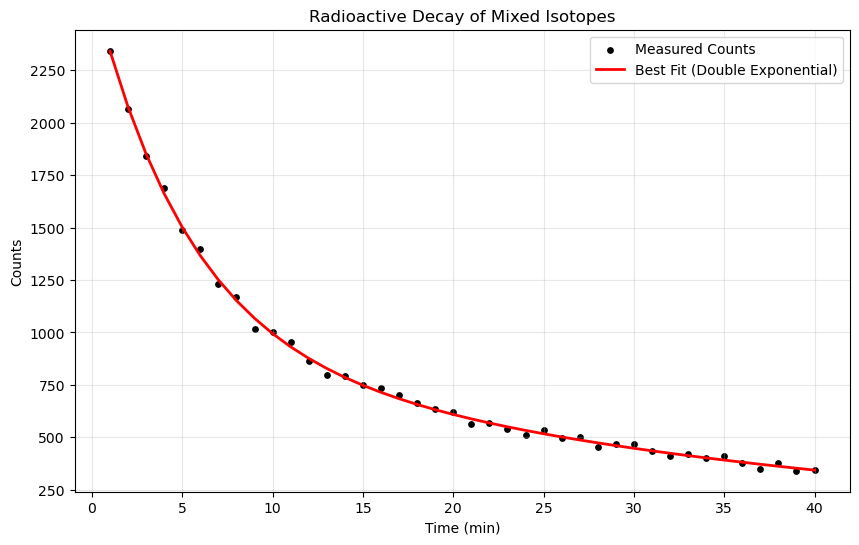

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

R=np.array([2343, 2066, 1839, 1690, 1490, 1397, 1232, 1171, 1017, 1000, 956, 864,
            795, 793, 748, 736, 703, 662, 636, 622, 564, 567, 541, 512, 534, 497,
            504, 456, 466, 469, 434, 410, 421, 400, 413, 380, 348, 376, 341, 344])

t=np.arange(1.0,41.0,1.0)

def decay(t,A,L1,B,L2,C):
    return A*np.exp(-L1*t)+B*np.exp(-L2*t)+C

C_g=300
A_g=1500
B_g=800

L2_g=np.linspace(0.01,0.1,100)
min_guess_B=float('inf')

for i in L2_g:
    B_guess= (R[20]-C_g)/np.exp(-i*t[20])
    pred = B_guess* np.exp(-i * t[20:]) + C_g
    guess = np.sum((R[20:] - pred)**2)
    if guess < min_guess_B:
        min_guess_B = guess
        best_L2=i
        
R_A=R[:10]-(1000*np.exp(-best_L2*t[:10])+C_g)            
L1_g=np.linspace(0.1,1,100)
min_guess_A=float('inf')

for i in L1_g:
    A_guess = R_A[0]/np.exp(-i * t[0])
    pred = A_guess * np.exp(-i * t[:10])
    guess = np.sum((R_A-pred)**2)
    if guess < min_guess_A:
        min_guess_A = guess
        best_L1=i

initial_p0 = [A_g, best_L1, B_g, best_L2, C_g]
# Set bounds: (lower_limits, upper_limits)
# Parameters are [A, L1, B, L2, C]
lower_bounds = [0, 0, 0, 0, 0]
upper_bounds = [5000, 2.0, 5000, 0.5, 400] 

popt, pcov = curve_fit(decay, t, R, p0=initial_p0, bounds=(lower_bounds, upper_bounds))

A, L1, B, L2, C = popt
errors = np.sqrt(np.diag(pcov))

print(f"Final Parameters:")
print(f" A = {A:.1f}, L1 = {L1:.4f}")
print(f" B = {B:.1f}, L2 = {L2:.4f}")
print(f" C = {C:.1f}")

# Half-lives
thalf1 = np.log(2) / L1
thalf2 = np.log(2) / L2
print(f"\nHalf-life 1: {thalf1:.2f} min")
print(f"Half-life 2: {thalf2:.2f} min")

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(t, R, label='Measured Counts', color='black', s=15)
plt.plot(t, decay(t, *popt), label='Best Fit (Double Exponential)', color='red', linewidth=2)
plt.xlabel('Time (min)')
plt.ylabel('Counts')
plt.title('Radioactive Decay of Mixed Isotopes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Problem 3.

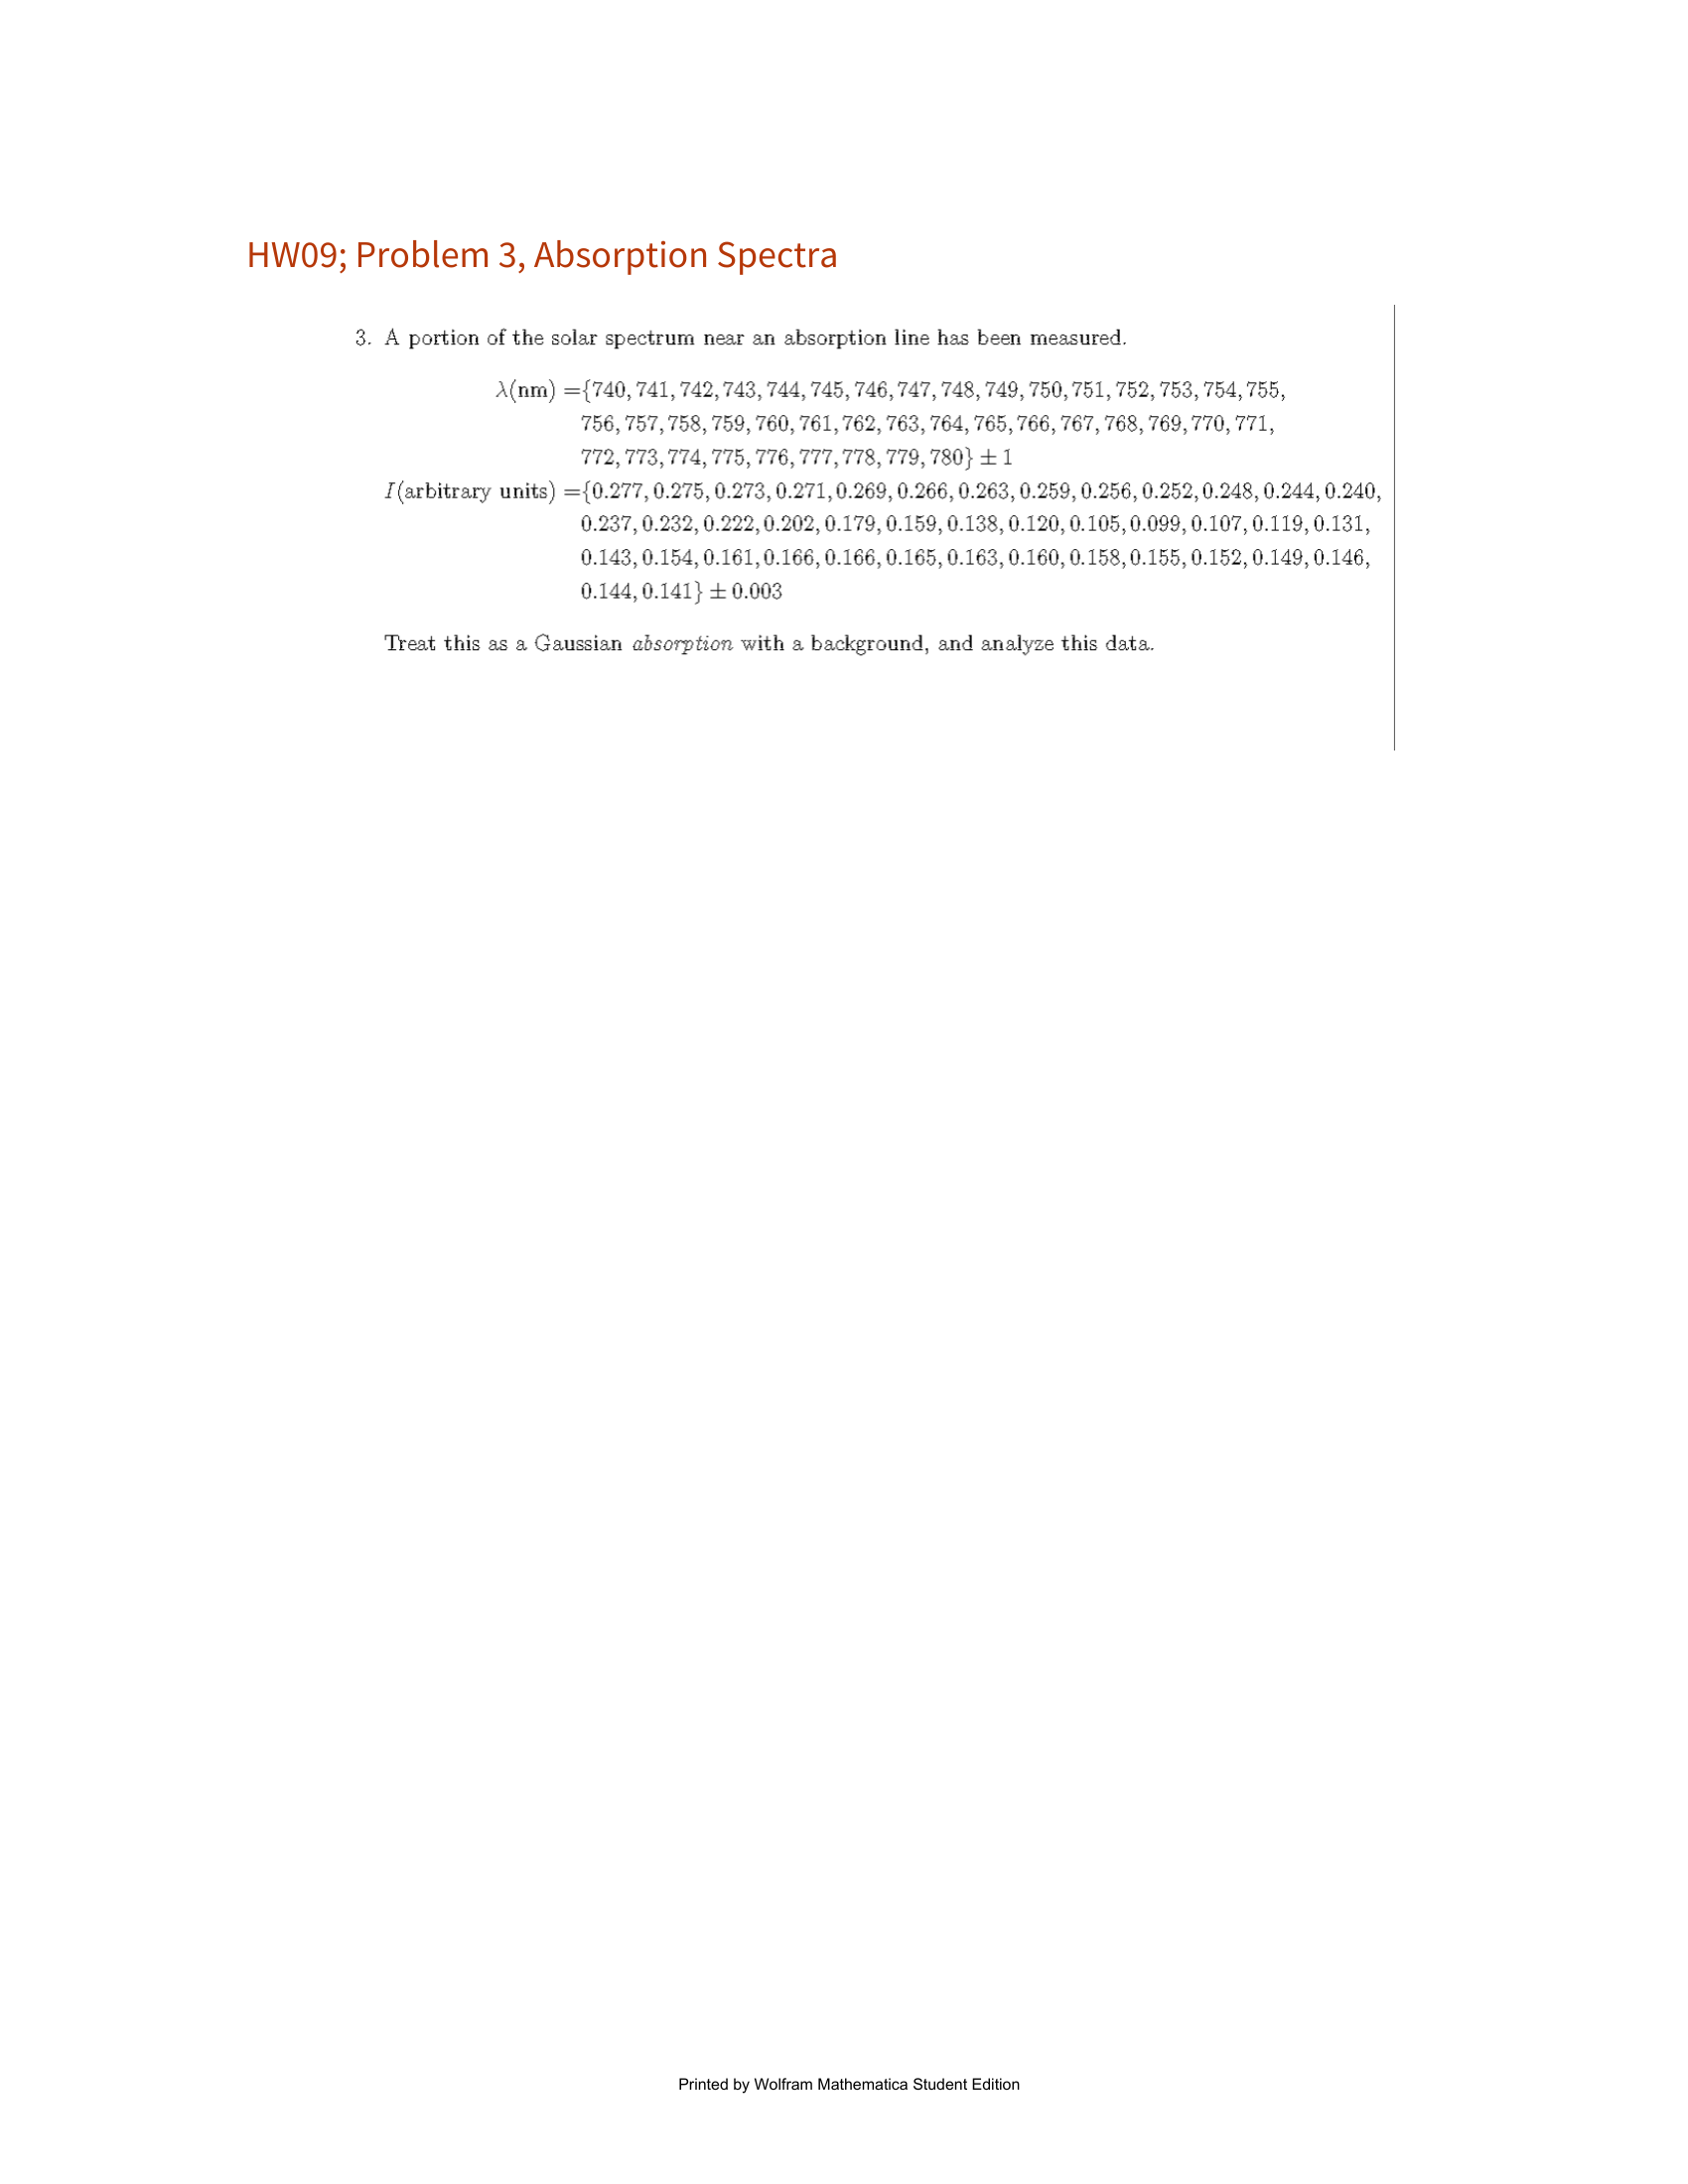

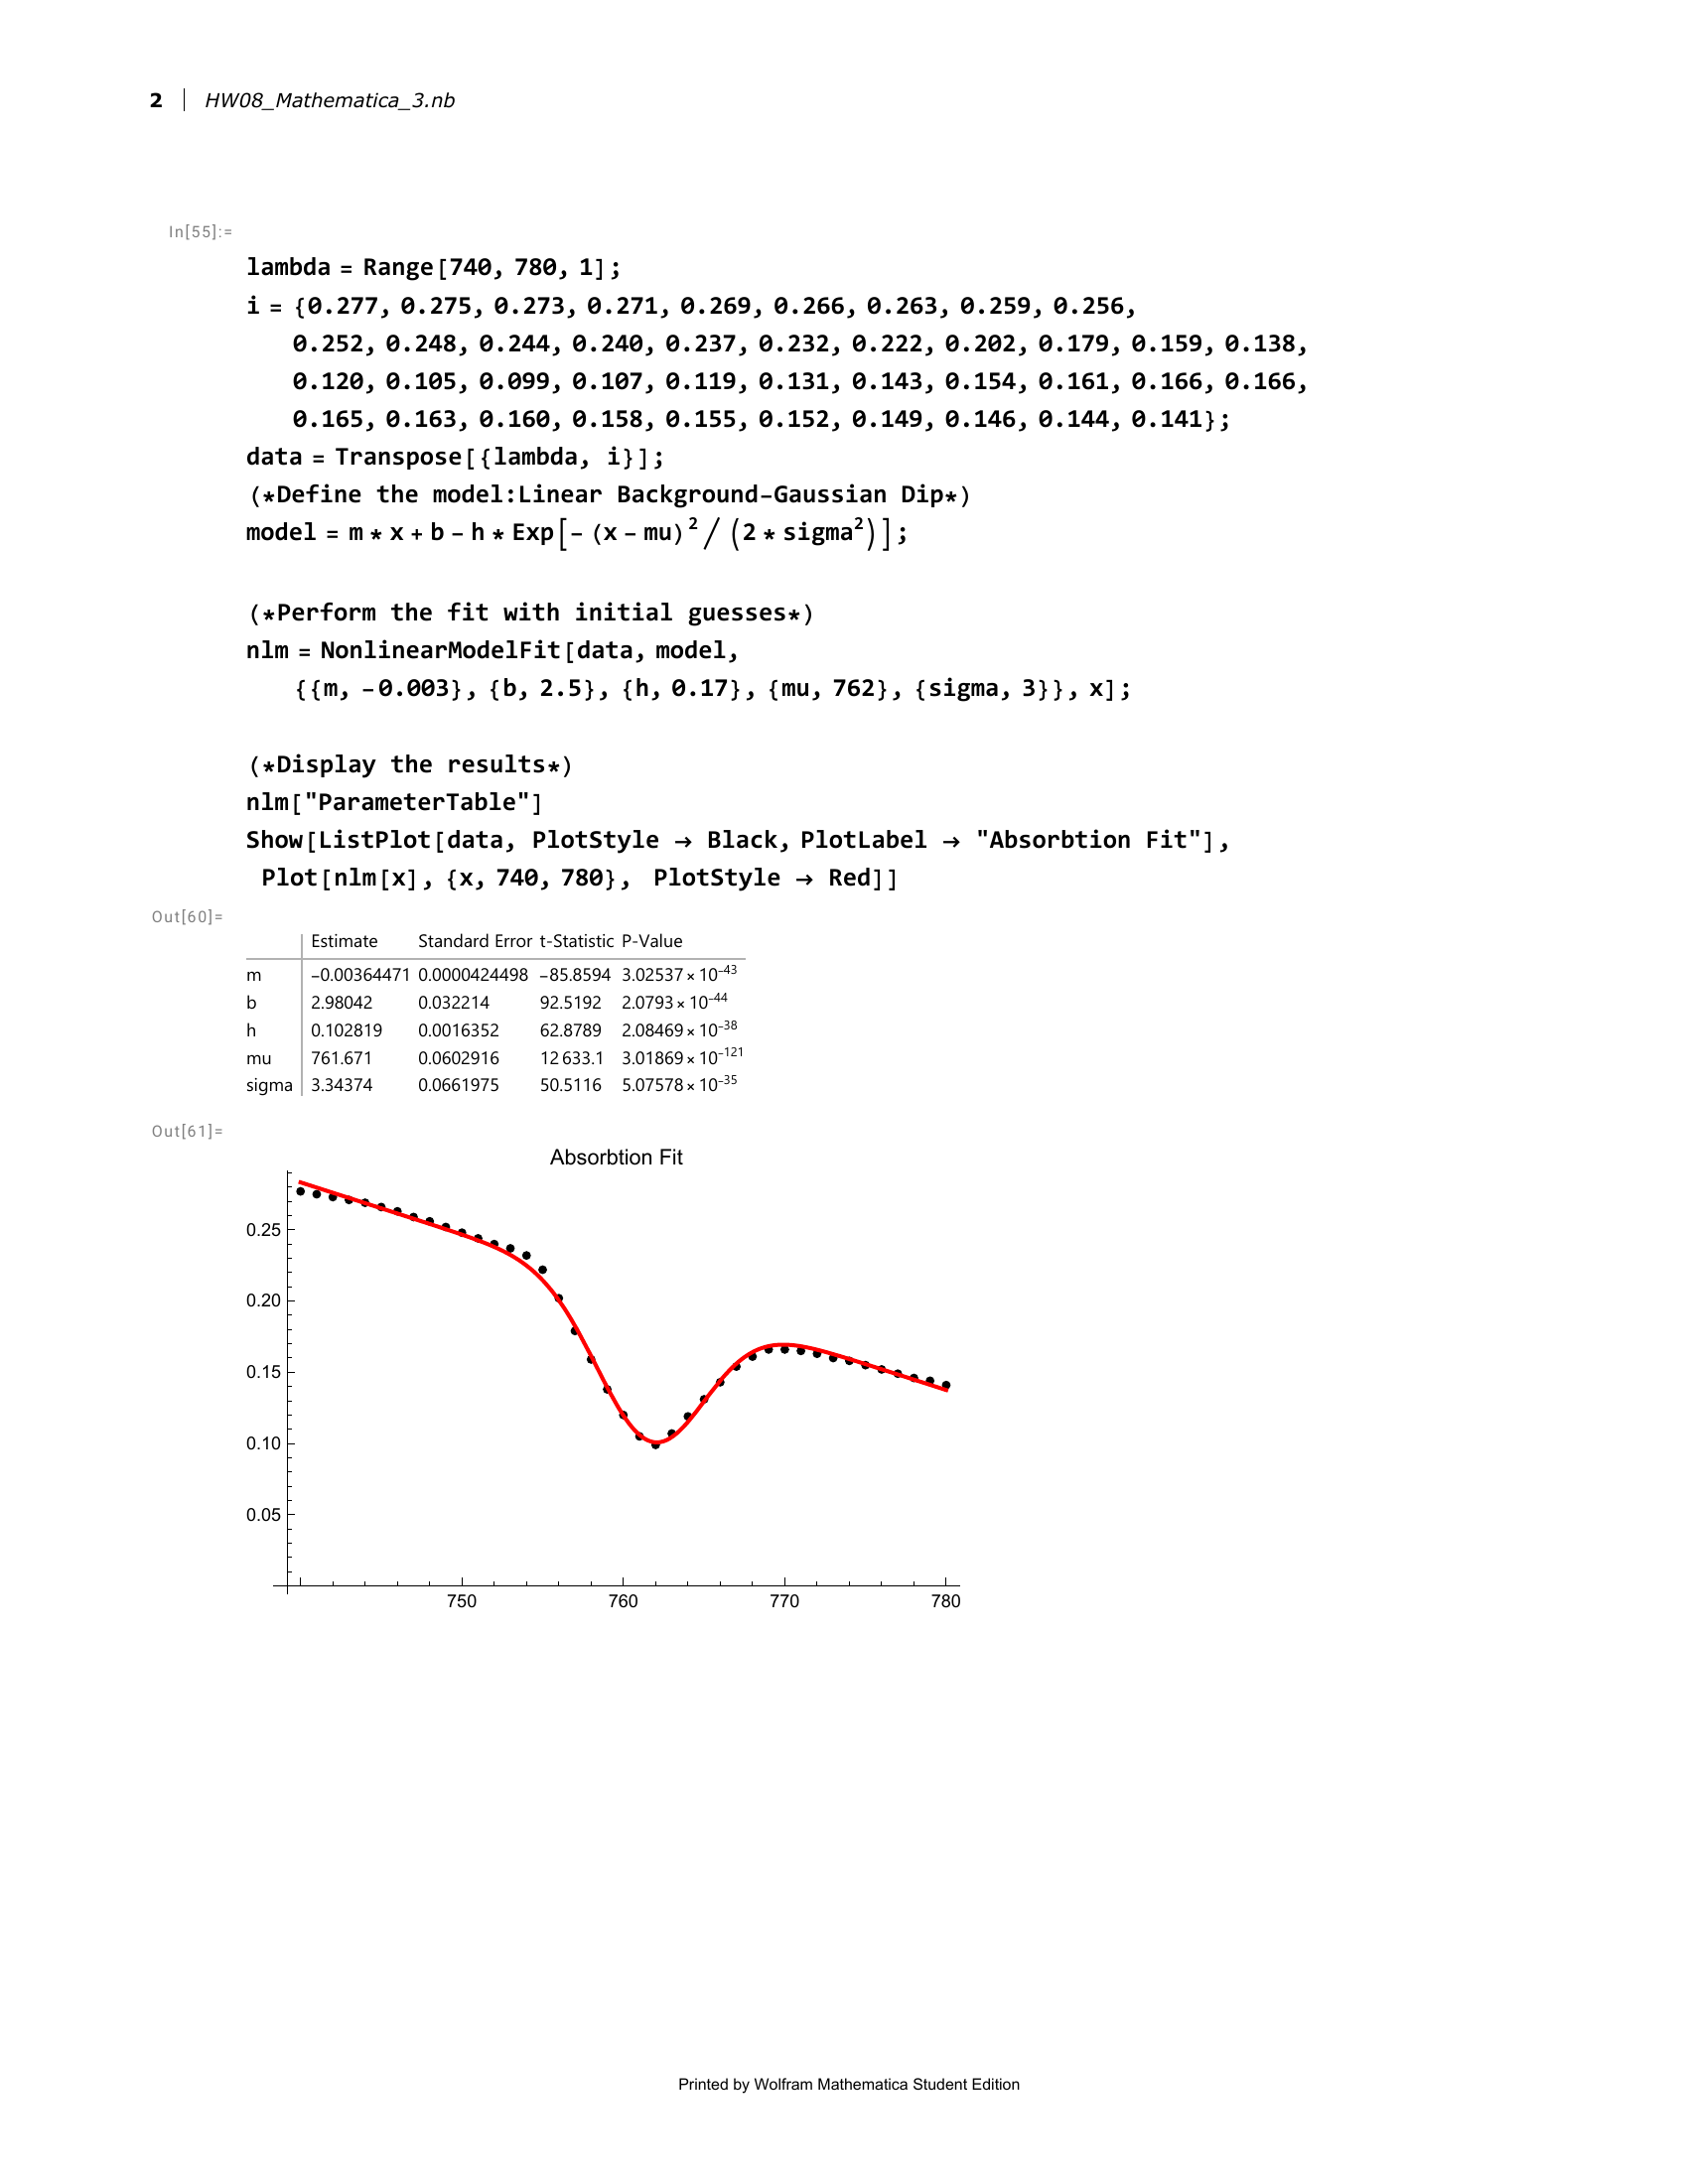

In [25]:
from pdf2image import convert_from_path
from IPython.display import display
images = convert_from_path(r"C:\Users\miles\BYU-Idaho\11th Semester\336 Advanced Lab\W08\HW08_Mathematica_3.pdf")
for img in images:
    display(img)

### Problem 4.

Final Parameters:
Peak 1 Amplitude:105.37 Mean: 31.00, Std:2.99 
Peak 2 Amplitude:55.72 Mean: 37.00, Std:2.01 


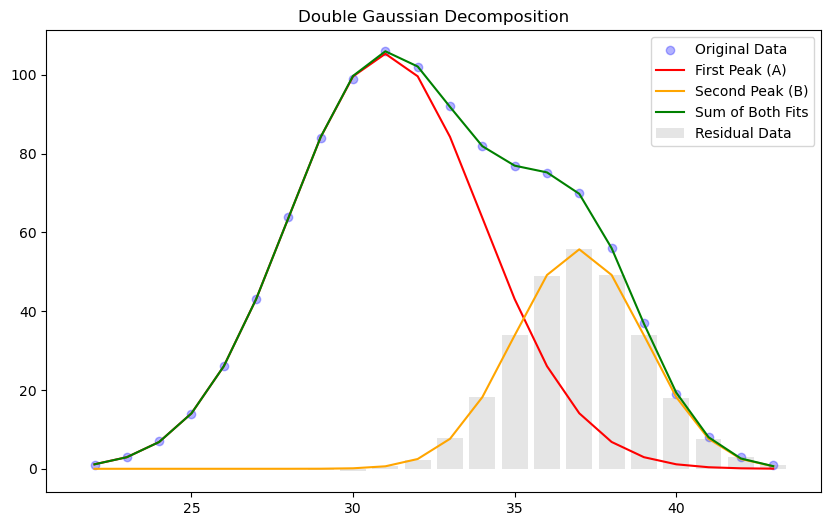

In [63]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from numpy.random import normal

pixel=np.arange(22,44)
counts=np.array([1, 3, 7, 14, 26, 43, 64, 84, 99, 106, 102, 
        92, 82, 77, 75, 70, 56, 37, 19, 8, 3, 1])


max_index=np.argmax(counts)
max_c=max(counts)
peak_pixel=pixel[max_index]
pA=pixel[:max_index+1]
cA=counts[:max_index+1]

def gauss(x,A,x1,sigma):
    return A*np.exp(-(x-x1)**2/2/sigma**2)

initial_guess=[max_c,peak_pixel,2]
lower_bounds = [0, peak_pixel - 0.001, 0.1]
upper_bounds = [np.inf, peak_pixel + 0.001, np.inf]
popt,pcov = curve_fit(gauss, pA,cA, p0=initial_guess, bounds=(lower_bounds, upper_bounds))

B_counts=counts-gauss(pixel, *popt)
initial_guess_B = [20,35,3]
popt2,pcov2 = curve_fit(gauss, pixel, B_counts, p0=initial_guess_B)

combined=B_counts+gauss(pixel, *popt)

print(f"Final Parameters:")
print(f"Peak 1 Amplitude:{popt[0]:.2f} Mean: {popt[1]:.2f}, Std:{popt[2]:.2f} ")
print(f"Peak 2 Amplitude:{popt2[0]:.2f} Mean: {popt2[1]:.2f}, Std:{popt2[2]:.2f} ")



plt.figure(figsize=(10, 6))
plt.scatter(pixel, counts, label='Original Data', color="blue", alpha=0.3)
plt.plot(pixel, gauss(pixel, *popt), color='red', label='First Peak (A)')
plt.plot(pixel, gauss(pixel, *popt2), color='orange', label='Second Peak (B)')
plt.plot(pixel, gauss(pixel, *popt) + gauss(pixel, *popt2), color='green', label='Sum of Both Fits')


plt.legend()
plt.title("Double Gaussian Decomposition")
plt.show()


### Problem 5. 

Slope (should be ~ -1): -0.983 ± 0.005
Lens Power: 6.45 ± 0.02 Diopters


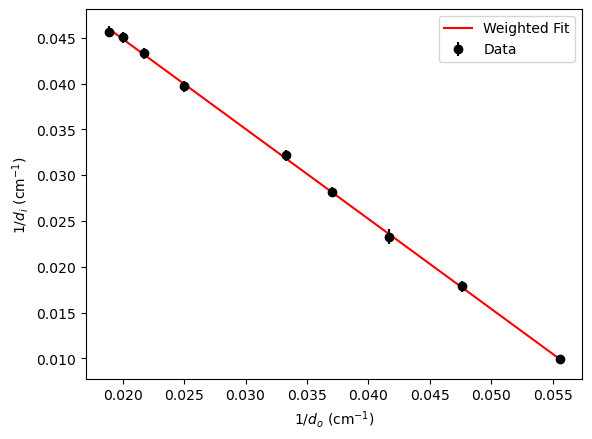

In [65]:

import numpy as np
import matplotlib.pyplot as plt

# Data
do = np.array([18.0, 21.0, 24.0, 27.0, 30.0, 40.0, 46.0, 50.0, 53.0])
ddo = 0.1 # cm

di = np.array([101.0, 56.0, 43.0, 35.5, 31.1, 25.2, 23.1, 22.2, 21.9])
ddi = np.array([3.0, 2.0, 1.5, 0.7, 0.6, 0.4, 0.3, 0.3, 0.3])

# Transform to linear space (Units: 1/cm)
x = 1/do
y = 1/di

# Note: Since do errors are very small, 
# we focus on di errors for the weights
sigma_y = ddi / (di**2)
weights = 1 / sigma_y

# Weighted Polyfit (degree 1 for a line)
# cov=True allows us to get the uncertainty of the fit parameters
params, cov = np.polyfit(x, y, 1, w=weights, cov=True)

m, b = params
dm, db = np.sqrt(np.diag(cov))

# Power is the intercept 'b' in units of 1/cm. 
# Convert to Diopters (1/m) by multiplying by 100.
power_diopters = b * 100
power_error = db * 100

print(f"Slope (should be ~ -1): {m:.3f} ± {dm:.3f}")
print(f"Lens Power: {power_diopters:.2f} ± {power_error:.2f} Diopters")

# Plotting
plt.errorbar(x, y, yerr=sigma_y, fmt='ko', label='Data')
plt.plot(x, m*x + b, 'r-', label='Weighted Fit')
plt.xlabel('$1/d_o$ (cm$^{-1}$)')
plt.ylabel('$1/d_i$ (cm$^{-1}$)')
plt.legend()
plt.show()